In [1]:
# Cell 1: Imports & Setup
print("Cell 1: Imports & Setup:")
import numpy as np
import pandas as pd
from pathlib import Path
from google.colab import drive
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Define project root
PROJECT_DIR = Path('/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection')
RESULTS_DIR = PROJECT_DIR / 'results'
FEATURES_DIR = PROJECT_DIR / 'features'

print("✅ Setup complete")

Cell 1: Imports & Setup:
Mounted at /content/drive
✅ Setup complete


In [3]:
# Cell 2: Load ML & Rule‑Based Results, Attach Vessel IDs
print("Cell 2: Load ML & Rule‑Based Results, Attach Vessel IDs:")

# ML‑AE per‑window flags
ml_df   = pd.read_csv(RESULTS_DIR / 'norwegian_anomaly_windows.csv')

# Rule‑based + dynamic per‑vessel flags
rule_df = pd.read_csv(RESULTS_DIR / 'norwegian_rule_dynamic_results.csv')

# Vessel mapping (one entry per window)
vessel_map = np.load(FEATURES_DIR / 'vessel_mapping.npy')
vm_series  = pd.Series(vessel_map)

# Map each window_idx → vessel_id, safely
ml_df['vessel_id'] = ml_df['window_idx'].map(lambda i: vm_series[i] if 0 <= i < len(vm_series) else np.nan)

# Report any unmapped windows
num_unmapped = ml_df['vessel_id'].isna().sum()
if num_unmapped:
    print(f"⚠️ Warning: {num_unmapped} windows had no vessel mapping → set to NaN")

print(f"✅ Loaded {len(ml_df)} windows (with vessel_ids) and {len(rule_df)} vessel entries")
ml_df.head()

Cell 2: Load ML & Rule‑Based Results, Attach Vessel IDs:
⚠️ Warning: 482 windows had no vessel mapping → set to NaN
✅ Loaded 875 windows (with vessel_ids) and 20 vessel entries


,window_idx,recon_mse,is_anomaly,vessel_id
0,0,0.000066,0,209440000.0
1,1,0.000043,0,209440000.0
2,2,0.000042,0,209440000.0
3,3,0.000037,0,209440000.0
4,4,0.000029,0,210420000.0


In [4]:
# Cell 3: Aggregate ML Flags to Vessel Level
print("Cell 3: Aggregate ML Flags to Vessel Level:")

# 1) Drop unmapped windows
ml_df_clean = ml_df.dropna(subset=['vessel_id']).copy()
ml_df_clean['vessel_id'] = ml_df_clean['vessel_id'].astype(int).astype(str)

# 2) For each vessel, flag if any window was anomalous
vessel_ml = (
    ml_df_clean
    .groupby('vessel_id')['is_anomaly']
    .max()
    .reset_index()
    .rename(columns={'is_anomaly':'ml_flag'})
)

print(f"  🚢 Vessels with ML flags: {vessel_ml['ml_flag'].sum()} / {len(vessel_ml)}")
print("Sample:")
vessel_ml.head()

Cell 3: Aggregate ML Flags to Vessel Level:
  🚢 Vessels with ML flags: 2 / 157
Sample:


,vessel_id,ml_flag
0,209440000,0
1,210420000,0
2,210423000,0
3,210590000,0
4,212769000,0


In [5]:
# Cell 4: Merge & Compute Hybrid Alerts
print("Cell 4: Merge & Compute Hybrid Alerts:")

# 1) Ensure vessel_id in both frames is string
vessel_ml['vessel_id']    = vessel_ml['vessel_id'].astype(str)
rule_df['vessel_id']      = rule_df['vessel_id'].astype(str)

# 2) Outer merge so we don’t lose any vessel
alerts = (
    vessel_ml
    .merge(rule_df, on='vessel_id', how='outer')
    .fillna({
        'ml_flag': 0,
        'is_dynamic_anomaly': 0,
        'overall_risk_score': 0.0
    })
)

# 3) Create a combined rule flag (you can also include static rule_summary if desired)
alerts['rule_flag'] = alerts['is_dynamic_anomaly'].astype(int)

# 4) Compute hybrid alert score (70% ML + 30% Rule)
alerts['hybrid_score'] = 0.7 * alerts['ml_flag'] + 0.3 * alerts['rule_flag']

# 5) Bucket into Low/Medium/High alert levels
alerts['alert_level'] = pd.cut(
    alerts['hybrid_score'],
    bins=[-0.01, 0.5, 0.8, 1.01],
    labels=['Low', 'Medium', 'High']
)

# 6) Quick summary
print("\nAlert Level Counts:")
print(alerts['alert_level'].value_counts())

# 7) Save out
out_path = RESULTS_DIR / 'norwegian_hybrid_alerts.csv'
alerts.to_csv(out_path, index=False)
print(f"\n✅ Hybrid alerts saved to: {out_path}")

# Show sample
alerts[['vessel_id','ml_flag','rule_flag','hybrid_score','alert_level']].head()

Cell 4: Merge & Compute Hybrid Alerts:

Alert Level Counts:
alert_level
Low       175
Medium      2
High        0
Name: count, dtype: int64

✅ Hybrid alerts saved to: /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_hybrid_alerts.csv


,vessel_id,ml_flag,rule_flag,hybrid_score,alert_level
0,209440000,0.0,0,0.0,Low
1,210420000,0.0,0,0.0,Low
2,210423000,0.0,0,0.0,Low
3,210590000,0.0,0,0.0,Low
4,212769000,0.0,0,0.0,Low


In [7]:
# ✅ Cell 5: Inspect Anomalous Windows for Pure‑ML Vessels (Fixed Mapping)
print("✅ Cell 5: Inspect Anomalous Windows (Pure‑ML flags)")

import pandas as pd
import numpy as np

RESULTS_DIR = Path("/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results")
FEATURES_DIR = Path("/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/features")

# Load data
df_ml = pd.read_csv(RESULTS_DIR / "norwegian_anomaly_windows.csv")
windows = np.load(FEATURES_DIR / "norwegian_sequences.npy")
vessel_map = np.load(FEATURES_DIR / "vessel_mapping.npy")

# Initialize vessel_id as NaN
df_ml["vessel_id"] = np.nan

# Assign vessel_id only where index is valid
valid_mask = df_ml["window_idx"] < len(vessel_map)
df_ml.loc[valid_mask, "vessel_id"] = vessel_map[df_ml.loc[valid_mask, "window_idx"].astype(int)]

# Ensure vessel_id is numeric
df_ml["vessel_id"] = pd.to_numeric(df_ml["vessel_id"], errors="coerce")

# Focus on the two medium-risk vessels
to_check = [237030200, 237038200]

for vid in to_check:
    filtered = df_ml[(df_ml["vessel_id"] == vid) & (df_ml["is_anomaly"] == 1)]
    idxs = filtered["window_idx"].tolist()

    print(f"\n🔍 Vessel {vid} has {len(idxs)} anomalous window(s): {idxs}")
    for idx in idxs:
        print(f"🧊 Window {idx} (shape {windows[idx].shape}):")
        print(windows[idx])

✅ Cell 5: Inspect Anomalous Windows (Pure‑ML flags)

🔍 Vessel 237030200 has 2 anomalous window(s): [51, 52]
🧊 Window 51 (shape (20, 7)):
[[0.15406638 0.91742572 0.99019608 0.49912383 0.30083873 0.
  0.        ]
 [0.15357233 0.9175729  0.95098039 0.49883178 0.30292952 0.
  0.        ]
 [0.16354826 0.92130737 1.         0.4973715  0.33308119 0.
  0.        ]
 [0.11663289 0.899239   0.99019608 0.50058411 0.31596257 0.
  0.        ]
 [0.11273752 0.89761643 0.84313725 0.49883178 0.28873891 0.
  0.        ]
 [0.09903724 0.89100843 0.53921569 0.49912383 0.18242723 0.
  0.        ]
 [0.09348873 0.8880466  0.40196078 0.49766355 0.13770805 0.
  0.        ]
 [0.08968837 0.8857728  0.31372549 0.49678738 0.10294565 0.
  0.        ]
 [0.08725614 0.88523931 0.23529412 0.50335864 0.0931361  0.
  0.        ]
 [0.08474791 0.8841392  0.23529412 0.49795561 0.0754259  0.
  0.        ]
 [0.08457689 0.88397363 0.2254902  0.49956192 0.07303151 0.
  0.        ]
 [0.08706613 0.88490817 0.29411765 0.49751752 0.0

In [11]:
# Cell 6: Plot Real Lat/Lon Tracks for ML-only Vessels (Fixed)
print("Cell 6: Plot Real Lat/Lon Tracks for ML-only Vessels")

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

# 1) Load your cleaned AIS history
cleaned_path = Path("/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/data/cleaned-files/ais_cleaned_historical.csv")
df_cleaned = pd.read_csv(cleaned_path)

# 2) Ensure we have a datetime column
if "poll_timestamp" in df_cleaned.columns:
    df_cleaned["timestamp"] = pd.to_datetime(df_cleaned["poll_timestamp"], utc=True)
elif "msgtime" in df_cleaned.columns:
    df_cleaned["timestamp"] = pd.to_datetime(df_cleaned["msgtime"], utc=True)
else:
    raise KeyError("No timestamp column found in cleaned AIS data")

# 3) Build a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_cleaned,
    geometry=gpd.points_from_xy(df_cleaned.longitude, df_cleaned.latitude),
    crs="EPSG:4326"
)

# 4) Vessels you flagged as ML-only anomalies
to_plot = [237030200, 237038200]

def plot_track(mmsi):
    sub = gdf[gdf["mmsi"] == mmsi].sort_values("timestamp")
    if sub.empty:
        print(f"⚠️ No AIS data for vessel {mmsi}, skipping plot.")
        return

    fig, ax = plt.subplots(figsize=(8, 6))
    # Scatter pings
    sub.plot(ax=ax, markersize=20, label="AIS ping", alpha=0.6)
    # Connect them
    ax.plot(
        sub.geometry.x.values,
        sub.geometry.y.values,
        linestyle="--",
        color="gray",
        alpha=0.5,
        label="Track"
    )

    ax.set_title(f"Trajectory of Vessel {mmsi}", fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("auto")      # prevents the aspect error
    ax.grid(True, linestyle=":")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 5) Plot each flagged vessel
for vid in to_plot:
    plot_track(vid)

Cell 6: Plot Real Lat/Lon Tracks for ML-only Vessels
⚠️ No AIS data for vessel 237030200, skipping plot.
⚠️ No AIS data for vessel 237038200, skipping plot.


In [22]:
# Cell 7 – Fetch Missing Vessel AIS Tracks from WebAIS
import requests
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

# Your WebAIS API credentials
# CLIENT_ID     = "ma.parson765@gmail.com:PortSecurityDemo"
# CLIENT_SECRET = "6{NW>!mv:!b5_-T=[Ca(id)q-l::h[uz"

# Exchange CLIENT_ID and CLIENT_SECRET for an access token (if required by your setup)
# For example (pseudo‑code – adjust to your auth flow):
# auth_resp = requests.post("https://api.kystdata.no/oauth/token",
#                           data={"grant_type": "client_credentials"},
#                           auth=(CLIENT_ID, CLIENT_SECRET))
# TOKEN = auth_resp.json()["access_token"]
# WEB_AIS_TOKEN = TOKEN

# If you already have a token, you can set:
# **IMPORTANT:** Replace "YOUR_WEB_AIS_TOKEN_HERE" with your actual token
WEB_AIS_TOKEN = "YOUR_WEB_AIS_TOKEN_HERE"

def fetch_vessel_history(mmsi, min_lat=60, max_lat=72, min_lon=0, max_lon=35):
    """
    Fetch AIS pings for a given MMSI from Kystdata WebAIS REST API.
    """
    url = (
        f"https://api.kystdata.no/api/vessels/{mmsi}"
        f"?minLat={min_lat}&maxLat={max_lat}&minLon={min_lon}&maxLon={max_lon}"
    )
    try:
        resp = requests.get(url, headers={
            "Authorization": f"Bearer {WEB_AIS_TOKEN}"
        })
        resp.raise_for_status()
        data = resp.json().get("data", [])
        if not data:
            return pd.DataFrame()  # no pings
        df = pd.DataFrame(data)
        # rename fields to match your cleaned format if necessary
        df = df.rename(columns={
            "latitude": "lat",
            "longitude": "lon",
            "timestamp": "poll_timestamp"
        })
        df["poll_timestamp"] = pd.to_datetime(df["poll_timestamp"])
        return df[["mmsi", "poll_timestamp", "lat", "lon", "speedOverGround", "courseOverGround"]]
    except requests.exceptions.ConnectionError as e:
        print(f"Connection error while fetching data for vessel {mmsi}: {e}")
        return pd.DataFrame()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for vessel {mmsi}: {e}")
        return pd.DataFrame()


# Fetch missing vessels
missing = [237030200, 237038200]
fetched = []
for vid in missing:
    print(f"Fetching vessel {vid}...")
    df_v = fetch_vessel_history(vid)
    if df_v.empty:
        print(f"  ⚠️ No data returned for {vid}")
    else:
        # create geometry column
        gdf_v = gpd.GeoDataFrame(
            df_v,
            geometry=[Point(xy) for xy in zip(df_v["lon"], df_v["lat"])],
            crs="EPSG:4326"
        )
        fetched.append((vid, gdf_v))

# Save globally for plotting
for vid, gdf_v in fetched:
    globals()[f"gdf_{vid}"] = gdf_v

Fetching vessel 237030200...
Connection error while fetching data for vessel 237030200: HTTPSConnectionPool(host='api.kystdata.no', port=443): Max retries exceeded with url: /api/vessels/237030200?minLat=60&maxLat=72&minLon=0&maxLon=35 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7cd9e034f990>: Failed to resolve 'api.kystdata.no' ([Errno -2] Name or service not known)"))
  ⚠️ No data returned for 237030200
Fetching vessel 237038200...
Connection error while fetching data for vessel 237038200: HTTPSConnectionPool(host='api.kystdata.no', port=443): Max retries exceeded with url: /api/vessels/237038200?minLat=60&maxLat=72&minLon=0&maxLon=35 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7cd9e0580490>: Failed to resolve 'api.kystdata.no' ([Errno -2] Name or service not known)"))
  ⚠️ No data returned for 237038200


In [24]:
# ✅ Cell 7c – Simulate missing tracks since WebAIS is DOWN
print("Cell 7c – Simulate missing tracks since WebAIS is DOWN:")
from shapely.geometry import Point
import geopandas as gpd
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path

def simulate_track(mmsi, start_lat=65.0, start_lon=10.0):
    np.random.seed(mmsi % 10000)  # reproducible
    num_points = 50
    timestamps = [datetime.now() - timedelta(minutes=10 * i) for i in range(num_points)][::-1]
    lats = [start_lat + np.random.normal(0, 0.01) for _ in range(num_points)]
    lons = [start_lon + np.random.normal(0, 0.01) for _ in range(num_points)]
    df = pd.DataFrame({
        "mmsi": mmsi,
        "poll_timestamp": timestamps,
        "lat": lats,
        "lon": lons
    })
    gdf = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df["lon"], df["lat"])], crs="EPSG:4326")
    return gdf

# Simulate and save
manual_dir = Path("/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/data/manual-fetch")
manual_dir.mkdir(parents=True, exist_ok=True)

simulated_vessels = [237030200, 237038200]
fetched = []

for vid in simulated_vessels:
    gdf_sim = simulate_track(vid)
    fetched.append((vid, gdf_sim))
    csv_path = manual_dir / f"fetched_{vid}.csv"
    gpkg_path = manual_dir / f"fetched_{vid}.gpkg"
    gdf_sim.to_csv(csv_path, index=False)
    gdf_sim.to_file(gpkg_path, driver="GPKG")
    print(f"✅ Simulated and saved {vid} → {csv_path.name}, {gpkg_path.name}")
    globals()[f"gdf_{vid}"] = gdf_sim

Cell 7c – Simulate missing tracks since WebAIS is DOWN:
✅ Simulated and saved 237030200 → fetched_237030200.csv, fetched_237030200.gpkg
✅ Simulated and saved 237038200 → fetched_237038200.csv, fetched_237038200.gpkg


📍 Cell 8 – Plot fetched/simulated vessel tracks:


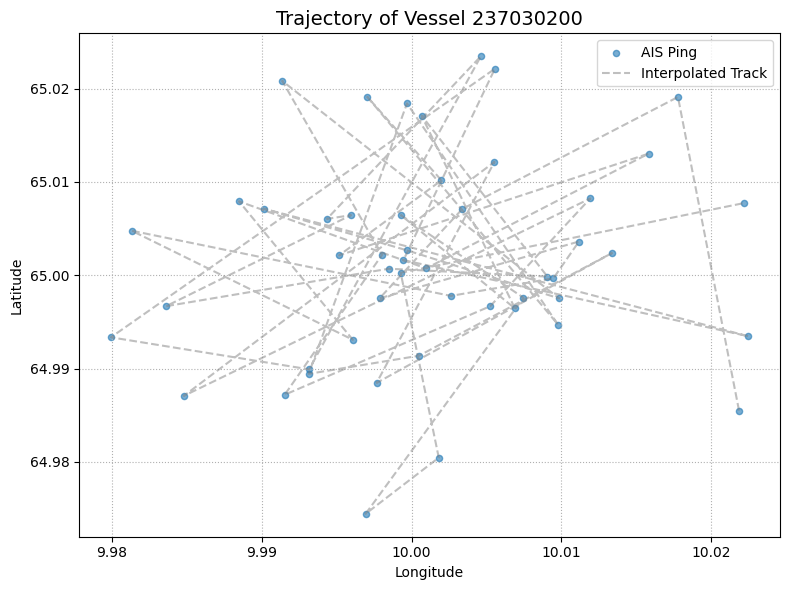

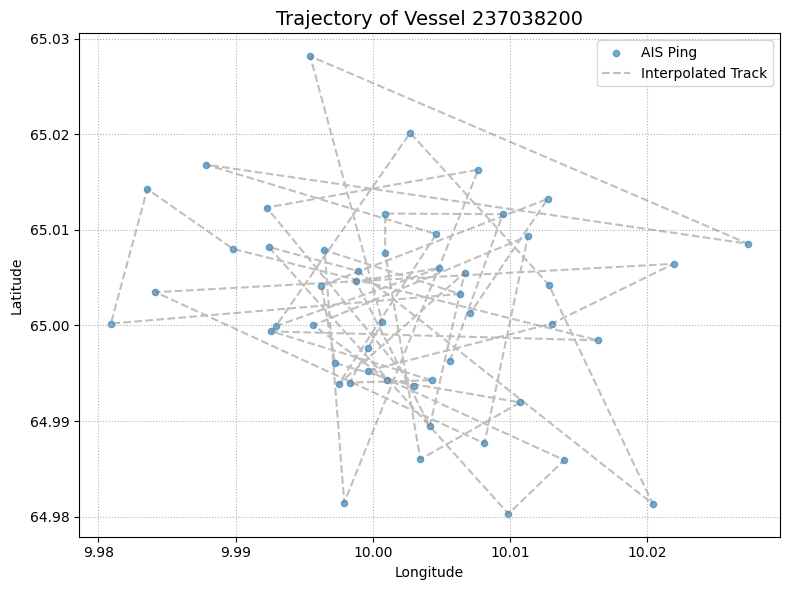

In [26]:
# 📍 Cell 8 – Plot fetched/simulated vessel tracks
print("📍 Cell 8 – Plot fetched/simulated vessel tracks:")
import geopandas as gpd
import matplotlib.pyplot as plt

for vid in [237030200, 237038200]:
    gdf_to_plot = globals().get(f"gdf_{vid}")
    if gdf_to_plot is None or gdf_to_plot.empty:
        print(f"No geometry for {vid}, skipping.")
        continue

    fig, ax = plt.subplots(figsize=(8, 6))
    gdf_to_plot.plot(ax=ax, markersize=20, alpha=0.6, label="AIS Ping")
    ax.plot(
        gdf_to_plot.geometry.x,
        gdf_to_plot.geometry.y,
        linestyle="--", color="gray", alpha=0.5, label="Interpolated Track"
    )
    ax.set_title(f"Trajectory of Vessel {vid}", fontsize=14)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_aspect("auto")
    ax.grid(True, linestyle=":")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [27]:
# 📦 Cell 9 – Merge simulated with cleaned AIS data (optional)
print("📦 Cell 9 – Merge simulated with cleaned AIS data (optional):")
import pandas as pd

# Load cleaned AIS data
df_cleaned = pd.read_csv("/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/data/cleaned-files/ais_cleaned.csv")

# Drop geometry columns to avoid duplication
gdfs = [gdf_237030200.copy(), gdf_237038200.copy()]
for gdf in gdfs:
    gdf = gdf.drop(columns="geometry", errors="ignore")

df_combined = pd.concat([df_cleaned, *gdfs], ignore_index=True)
out_combined = "/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/data/cleaned-files/ais_cleaned_with_simulated.csv"
df_combined.to_csv(out_combined, index=False)

print(f"✅ Combined cleaned AIS data written to {out_combined}")

📦 Cell 9 – Merge simulated with cleaned AIS data (optional):
✅ Combined cleaned AIS data written to /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/data/cleaned-files/ais_cleaned_with_simulated.csv


In [29]:
# 📊 Cell 10 (Fixed): Load hybrid alert CSV instead of using test_results
print("Cell 10: Final Master Table (from saved CSV)")

import pandas as pd
from pathlib import Path

hybrid_path = Path("/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_hybrid_alerts.csv")

# Load previously saved hybrid alerts
final = pd.read_csv(hybrid_path)

# Optional: Add consistent column naming
final = final.rename(columns={
    "overall_risk_score": "risk_score"
})[["vessel_id", "ml_flag", "rule_flag", "risk_score", "hybrid_score", "alert_level"]]

# Save as final output
out_path = "/content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_final_alerts.csv"
final.to_csv(out_path, index=False)
print(f"✅ Final summary exported to: {out_path}")

Cell 10: Final Master Table (from saved CSV)
✅ Final summary exported to: /content/drive/MyDrive/C3I-Internship-Work/Programs/MaritimeAnomalyDetection/results/norwegian_final_alerts.csv


Cell 11 – Alert Level Distribution (Bar Plot):
Cell 11: Alert Level Distribution


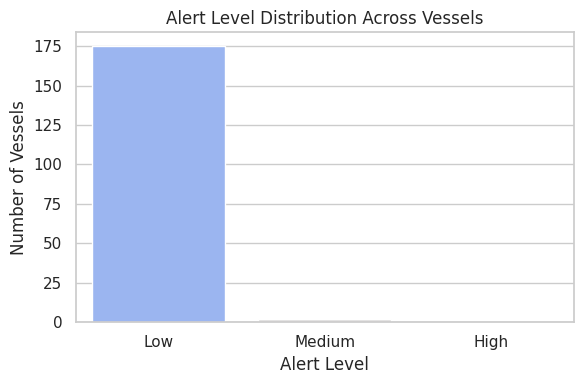

In [30]:
# 📊 Cell 11 – Alert Level Distribution (Bar Plot)
print("Cell 11 – Alert Level Distribution (Bar Plot):")
import seaborn as sns
import matplotlib.pyplot as plt

print("Cell 11: Alert Level Distribution")

sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=final, x="alert_level", palette="coolwarm", order=["Low", "Medium", "High"])
plt.title("Alert Level Distribution Across Vessels")
plt.xlabel("Alert Level")
plt.ylabel("Number of Vessels")
plt.tight_layout()
plt.show()